In [42]:
import numpy as np
from energyflow import EFPSet
from energyflow.utils import gen_massless_phase_space
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib as mpl


In [43]:
def compute_cov(X):
    """Covariance matrix from event matrix X. Returns (cov, mask)."""
    Xc  = X - X.mean(axis=0)
    cov = (Xc.T @ Xc) / X.shape[0]
    cov = (cov + cov.T) / 2
    mask = None
    return cov, mask


def compute_cor(cov, mask=None):
    """Correlation matrix from covariance, restricted to masked features."""
    if mask is None:
        mask = np.diag(cov) > 0
    sub = cov[np.ix_(mask, mask)]
    var = np.diag(sub)
    D   = np.diag(1.0 / np.sqrt(var))
    cor = D @ sub @ D
    return (cor + cor.T) / 2


def compute_spectrum(mat):
    """Eigenvalue spectrum of symmetric matrix, sorted descending."""
    return np.flip(np.linalg.eigh(mat)[0])


def compute_whitener(cov_ref, rcond=1e-10):
    """PCA-whitening map from a reference covariance.
    Returns W (p x r) with W.T @ cov_ref @ W = I_r."""
    w, U = np.linalg.eigh(cov_ref)
    w, U = w[::-1], U[:, ::-1]
    keep = w > rcond * w[0]
    Ur, wr = U[:, keep], w[keep]
    W = Ur / np.sqrt(wr)
    return W, keep


def whiten_cov(cov, W):
    """Express a covariance in the uniform-whitened basis: r x r."""
    return W.T @ cov @ W

In [44]:
## Generate uniform phase-space samples

ecm=91.188
n_w      = 10000  # whitener
n_uni_test = 10000  # independent held-out sample

efpset = EFPSet(('d<=', 6), ('e>=1'), measure='eeefm', beta=2,
                coords='epxpypz', normed=True)

file_indices = [1, 3, 5, 7]  # splittings_k.npy -> N = k+2
Data = {}
for k in file_indices:
    N      = k + 2
    Data[N] = dict(EFPs_pyth=None, n_events=None)

for N in sorted(Data.keys()):
    unif      = gen_massless_phase_space(n_w,      N, energy=ecm)
    unif_test = gen_massless_phase_space(n_uni_test, N, energy=ecm)
    Data[N].update(
        EFPs_unif      = efpset.batch_compute(unif),
        EFPs_unif_test = efpset.batch_compute(unif_test),
    )
    print(f"N={N}: uniforms done")

print("\nDone.")

N=3: uniforms done
N=5: uniforms done
N=7: uniforms done
N=9: uniforms done

Done.


In [45]:
##Note: here if rcond is changed to 0, we get the full spectrum
# without disposing of any directions that the whitening would reduce,
# since the whitening disposes of directions in which the whitener matrix has small eigenvalues (<lambda_max*rcond)
def compute_results(Data, rcond=1e-10, verbose=True):
    Results = {}
    if verbose:
        print(f"rcond={rcond}")
    for N, d in Data.items():
        # cov_pyth,      _ = compute_cov(d['EFPs_pyth'])
        cov_unif,      _ = compute_cov(d['EFPs_unif'])
        cov_unif_test, _ = compute_cov(d['EFPs_unif_test'])
        W, keep          = compute_whitener(cov_unif, rcond=rcond)
        r                = W.shape[1]
        if verbose:
            print(f"  N={N}: r={r} directions kept")
        Results[N] = dict(
            n_events           = d['n_events'],
            W                  = W,
            keep               = keep,
            r                  = r,
            # ev_white_pythia    = compute_spectrum(whiten_cov(cov_pyth,      W)),
            ev_white_unif      = compute_spectrum(whiten_cov(cov_unif,      W)),
            ev_white_unif_test = compute_spectrum(whiten_cov(cov_unif_test, W)),
            # ev_cov_pythia      = compute_spectrum(cov_pyth)[:r],
            ev_cov_unif        = compute_spectrum(cov_unif)[:r],
            ev_cov_unif_test   = compute_spectrum(cov_unif_test)[:r],
        )
    return Results


Results = compute_results(Data)

rcond=1e-10
  N=3: r=7 directions kept
  N=5: r=32 directions kept
  N=7: r=35 directions kept
  N=9: r=35 directions kept


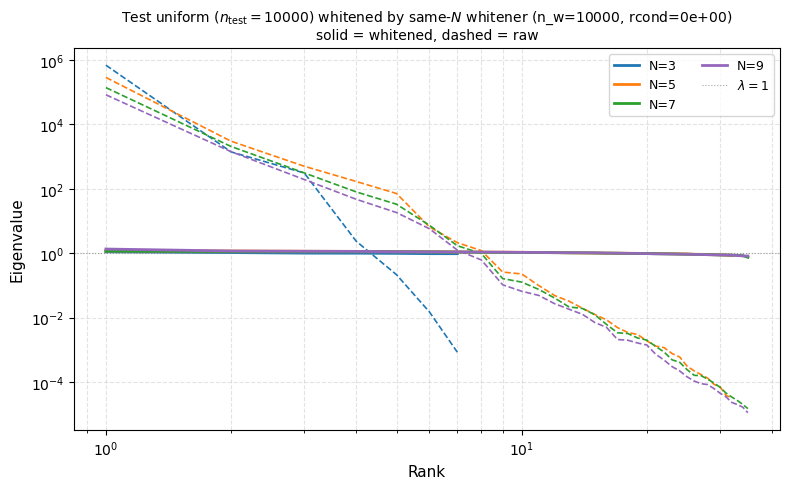

In [46]:
from matplotlib.lines import Line2D

N_values   = [3, 5, 7, 9]
rcond_plot = 0

colors = plt.cm.tab10(np.linspace(0, 0.4, len(N_values)))
c_map  = {N: colors[i] for i, N in enumerate(N_values)}

plt.figure(figsize=(8, 5))

# ── Test uniform self-whitened ────────────────────────────────────────────────
for N in N_values:
    d     = Results[N]
    ranks = np.arange(1, d['r'] + 1)
    plt.plot(ranks, d['ev_cov_unif_test'],   color=c_map[N], ls='--', lw=1.2)
    plt.plot(ranks, d['ev_white_unif_test'], color=c_map[N], ls='-',  lw=2.0,
             label=f"N={N}")
plt.axhline(1, color='gray', lw=0.8, ls=':', alpha=0.7, label=r'$\lambda=1$')
plt.xscale('log'); plt.yscale('log')
plt.xlabel("Rank", fontsize=11)
plt.ylabel("Eigenvalue", fontsize=11)
plt.title(
    f"Test uniform ($n_\\mathrm{{test}}={n_uni_test}$) whitened by same-$N$ whitener (n_w={n_w}, rcond={rcond_plot:.0e})\n"
    f"solid = whitened, dashed = raw",
    fontsize=10
)
plt.legend(fontsize=9, ncol=2)
plt.grid(True, which='both', ls='--', alpha=0.35)

#Note: These can be uncommented for the r=0 version, to retain the cropping induced by the r=1e-10 .
# plt.xlim(1,40)
# plt.ylim(1e-4,1e6)

plt.tight_layout()
plt.show()